# Hybrid Energy Model - Getting Started

This notebook walks through the whole pipeline:

1. Generate (synthetic) hourly **load**, **solar**, and **wind** profiles for a year
2. Build a PyPSA network: solar + wind + battery + grid connection
3. Optimize component sizes (capacity expansion) to minimize total annual cost
4. Look at the results: optimal sizes, cost breakdown, and hour-by-hour dispatch

Everything below uses **made-up example data** so you can run it right away.
Once you're comfortable, swap in your own CSVs (see the README).

In [1]:
import matplotlib.pyplot as plt

from hybrid_energy import data, model, plotting

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 4)

## 1. Generate example profiles (one full year, hourly)

In [2]:
N_HOURS = 24 * 365  # one year, hourly resolution

load_kw = data.synthetic_load_profile(n_hours=N_HOURS)
solar_cf = data.synthetic_solar_cf(n_hours=N_HOURS)
wind_cf = data.synthetic_wind_cf(n_hours=N_HOURS)

load_kw.head()

2024-01-01 00:00:00    60.843783
2024-01-01 01:00:00    60.053739
2024-01-01 02:00:00    65.222924
2024-01-01 03:00:00    65.396509
2024-01-01 04:00:00    67.331081
Freq: h, Name: load_kw, dtype: float64

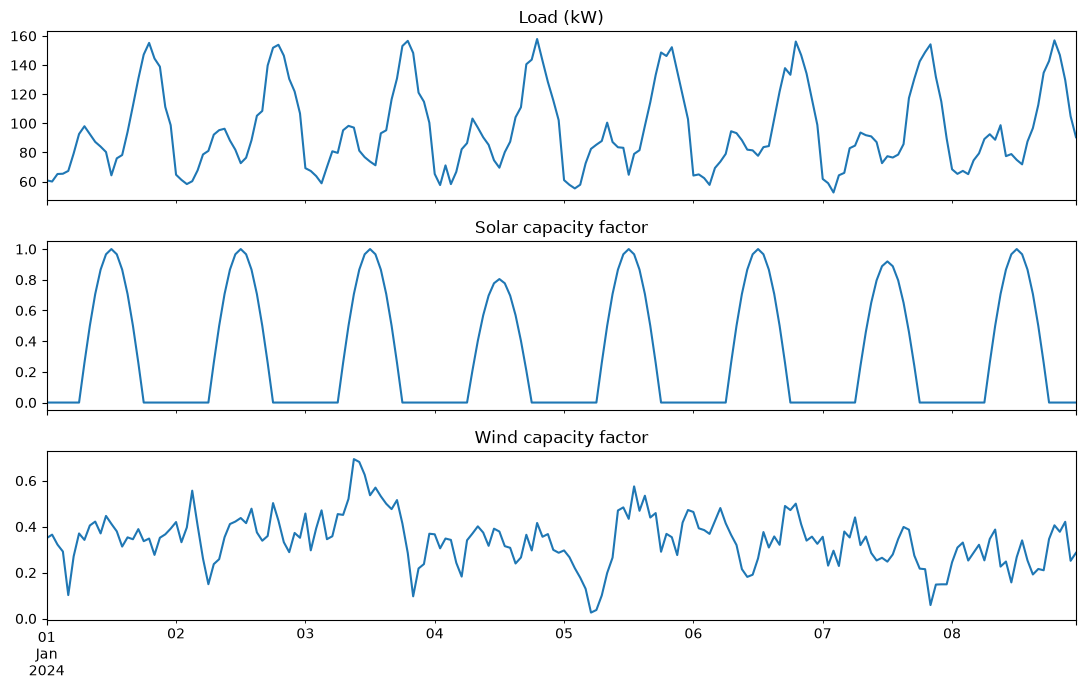

In [3]:
# Sanity-check the shapes over a sample week
window = slice("2024-01-01", "2024-01-08")

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
load_kw.loc[window].plot(ax=axes[0], title="Load (kW)")
solar_cf.loc[window].plot(ax=axes[1], title="Solar capacity factor")
wind_cf.loc[window].plot(ax=axes[2], title="Wind capacity factor")
plt.tight_layout()

## 2. Build the network

One electrical bus with:
- a **solar** generator and a **wind** generator (both size-optimizable)
- a **battery** (`StorageUnit`, size-optimizable, 4-hour duration)
- a **grid connection** you can import from (at a per-MWh price)
- a small "unmet demand" slack generator with a very high cost, just so the
  optimization always has a feasible fallback instead of failing outright

Cost assumptions live in `hybrid_energy/model.py::DEFAULT_COSTS` - they're
illustrative placeholders, not real quotes. Override any of them by passing
a `costs=` dict to `build_network`.

In [4]:
network = model.build_network(
    load_kw=load_kw,
    solar_cf=solar_cf,
    wind_cf=wind_cf,
    battery_max_hours=4.0,
    grid_available=True,
)

status, condition = model.optimize_capacity(network)
print(status, condition)

/home/user/d-murphy16/hybrid-energy-model/.venv/lib/python3.11/site-packages/pypsa/network/io.py:2082: FutureWarning: pandas infers the `str` dtype for string data since its version 3.0. PyPSA still converts it back to numpy object dtype on import, but will keep it from PyPSA 2.0 on. Set `pypsa.options.api.legacy_string_dtype` explicitly to suppress this warning.
  new_static = _coerce_string_dtypes(new_static)
/home/user/d-murphy16/hybrid-energy-model/hybrid_energy/model.py:108: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  return n.optimize(solver_name=solver_name)
Index(['main'], dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.io:Writing objective.


Writing constraints.:   0%|          | 0/14 [00:00<?, ?it/s]

Writing constraints.:  57%|█████▋    | 8/14 [00:00<00:00, 75.09it/s]

...

      36414     4.6885614771e+04 Pr: 0(0); Du: 0(2.78931e-10) 4.6s

Performed postsolve
Solving the original LP from the solution after postsolve



Model name          : linopy-problem-myxh7m7r
Model status        : Optimal
Simplex   iterations: 36414
Objective value     :  4.6885614771e+04
P-D objective error :  1.0707670658e-14
HiGHS run time      :          4.85


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61323 primals, 140163 duals
Objective: 4.69e+04
Solver: highs
Runtime: 4.85s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


ok optimal


## 3. Results: optimal sizing and cost breakdown

In [5]:
model.capacity_summary(network)

,type,p_nom_opt_MW,energy_capacity_opt_MWh
component,,,
solar,generator,0.089523,NaN
wind,generator,0.252614,NaN
grid_import,generator,100000.000000,NaN
battery,storage,0.062782,0.251129


In [6]:
model.cost_summary(network)

{'capital_cost_per_year': 35012.6980313302,
 'operational_cost_per_year': 11948.686721537588,
 'total_cost_per_year': 46961.38475286779,
 'unmet_demand_MWh': 0.0}

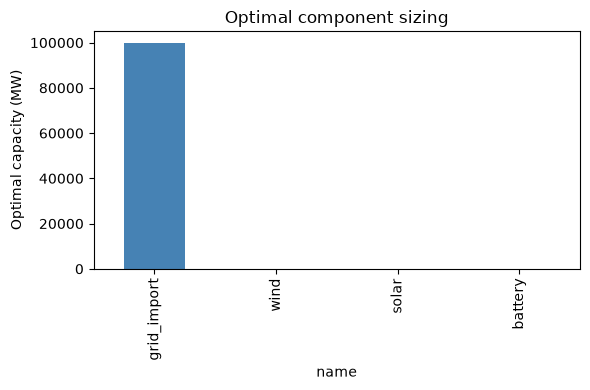

In [7]:
plotting.plot_capacities(network)
plt.tight_layout()

## 4. Hour-by-hour dispatch (a sample week)

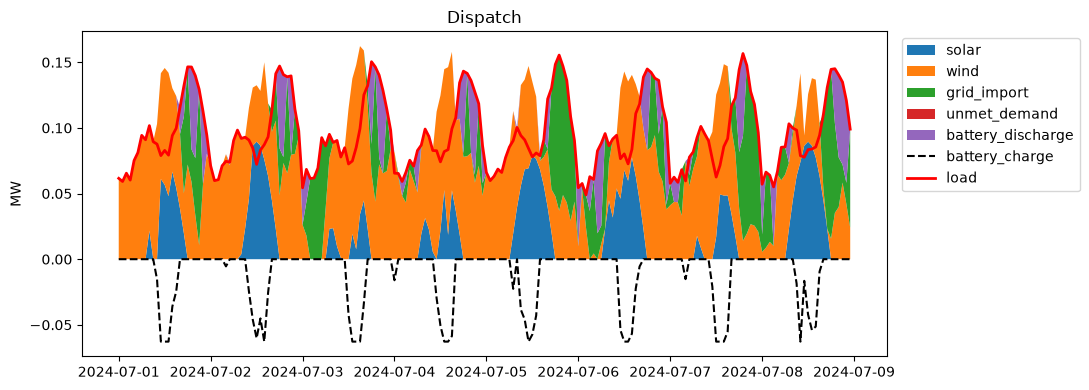

In [8]:
plotting.plot_dispatch(network, start="2024-07-01", end="2024-07-08")
plt.tight_layout()

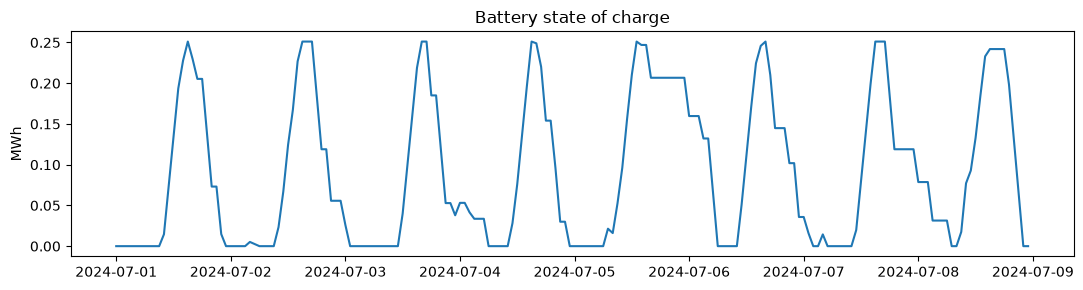

In [9]:
plotting.plot_state_of_charge(network, start="2024-07-01", end="2024-07-08")
plt.tight_layout()

## Next steps

- **Use your own data:** replace the three `data.synthetic_*` calls above with
  `data.load_profile_csv("../data/your_file.csv")` for load, solar, and wind.
- **Change the system:** try `grid_available=False` for an off-grid design, or
  change `battery_max_hours`.
- **Change the economics:** pass your own `costs={...}` dict to `build_network`
  (see `DEFAULT_COSTS` in `hybrid_energy/model.py` for the keys).
- **Compare scenarios:** build two networks with different assumptions and
  compare `model.cost_summary(...)` side by side.